# Radar Data Visualisation

PyEarthTools does not (yet) have its own dedicated plotting and data visualisation API. However, visualising Earth system data is something that users of PyEarthTools are likely to want to do. The focus of this notebook is on how to visualise data.

Additionally, there has been a lot of interest by users in examples with lower requirements for data volumes for people outside of HPC facilities. For that reason, this notebook uses a dataset which doesn't have a pre-built data accessor, and the data is loaded directly with xarray. NCI (Australia) users are more likely to work with the merged radar dataset using `petdata.archive.Rainfields3(variables='prcp-crate')`. If there is user interest, a single-radar accessor could be provided, but it is not needed for this example.

This notebook will download a little under 70MB. The notebook itself stores just under 40MB of data in the interactive plot object as binary data.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [3]:
import xarray as xr
import numpy as np
import zipfile
import urllib.request
from io import BytesIO

import plotly.io as pio
pio.renderers.default = "notebook"
import plotly
import plotly.graph_objects as go

# Loading Data

This data could be loaded using a PyEarthTools data accessor, however to simplify the notebook and base it on downloading data rather than using a pre-existing accessor, a direct xarray file open has been used. This makes it more suitable for new users, those not in dedicated high performance computing facilities, or those who have not downloaded an archive of radar data on disk.

The data will be loaded from the NCI data servers and is covered by a CC4.0-BY-NC license.

See [https://opus.nci.org.au/spaces/NDP/pages/399803502/Australian+Unified+Radar+Archive](https://opus.nci.org.au/spaces/NDP/pages/399803502/Australian+Unified+Radar+Archive) for more information.

Users at NCI wanting to access this data frequently or as a time-series for machine learnind should construct or request PyEarthTools data accessor which will load data from disk for improved performance.

In [4]:
import os

project_path = '/content/drive/MyDrive/BOM'

In [5]:
# This loads one specific day of data for one specific radar
'''target_url = 'https://thredds.nci.org.au/thredds/fileServer/rq0/level_1b/2/grid/2024/2_20240402_grid.zip'
data = urllib.request.urlopen(target_url).read()
bytes_io = BytesIO(data)'''
z = zipfile.ZipFile(os.path.join(project_path, '2_20240402_grid.zip'), 'r')
# namelist = z.namelist()
# opened = [z.open(name) for name in namelist]

# Only load every Nth file instead of all
N = 10  # adjust as needed
namelist = z.namelist()
namelist_subset = namelist[::N]  # every 10th file

opened = [z.open(name) for name in namelist_subset]
each_few_minutes = [xr.open_dataset(o) for o in opened]
radar = xr.concat(each_few_minutes, dim='time', data_vars='all')
radar = radar.sortby('time')

'''each_few_minutes = [xr.open_dataset(o) for o in opened]
radar = xr.concat(each_few_minutes, dim='time', data_vars='all')
radar = radar.sortby('time')'''

"each_few_minutes = [xr.open_dataset(o) for o in opened]\nradar = xr.concat(each_few_minutes, dim='time', data_vars='all')\nradar = radar.sortby('time')"

In [6]:
radar # Display radar data structure metadata

<xarray.Dataset> Size: 2GB
Dimensions:                     (time: 29, nradar: 1, z: 41, y: 301, x: 301)
Coordinates:
  * time                        (time) datetime64[ns] 232B 2024-04-02T00:19:2...
  * z                           (z) float64 328B 0.0 500.0 ... 1.95e+04 2e+04
  * y                           (y) float64 2kB -1.5e+05 -1.49e+05 ... 1.5e+05
  * x                           (x) float64 2kB -1.5e+05 -1.49e+05 ... 1.5e+05
Dimensions without coordinates: nradar
Data variables: (12/21)
    origin_latitude             (time) float64 232B -37.86 -37.86 ... -37.86
    origin_longitude            (time) float64 232B 144.8 144.8 ... 144.8 144.8
    origin_altitude             (time) float64 232B 45.0 45.0 45.0 ... 45.0 45.0
    projection                  (time) int32 116B 1 1 1 1 1 1 1 ... 1 1 1 1 1 1
    ProjectionCoordinateSystem  (time) int32 116B 1 1 1 1 1 1 1 ... 1 1 1 1 1 1
    radar_latitude              (time, nradar) float64 232B -37.86 ... -37.86
    ...                          ...
    azshear                     (time, z, y, x) float32 431MB nan nan ... nan
    longitude                   (time, y, x) float32 11MB 143.0 143.0 ... 146.4
    latitude                    (time, y, x) float32 11MB -39.19 ... -36.49
    profile_temperature         (time, z) float32 5kB 14.2 12.37 ... -59.15
    profile_relative_humidity   (time, z) float32 5kB 79.4 86.73 ... 2.562 2.203
    profile_pressure            (time, z) float32 5kB 997.2 952.7 ... 56.21
Attributes: (12/52)
    summary:                   Level 1b dataset from the Australian radar net...
    history:                   created by Joshua Soderholm on gadi.nci.org.au...
    acknowledgement:           This work is support by the Bureau of Meteorol...
    institution:               Bureau of Meteorology
    keywords:                  radar, Doppler, dual-polarization
    licence:                   CC4.0-BY-NC (if the latest dataset licence if ...
    ...                        ...
    grid_vert_range_m:         20000
    grid_horz_range_m:         150000.0
    grid_vert_shape:           41
    grid_horz_shape:           301
    grid_vert_resolution_m:    500.0
    grid_horz_resolution_m:    1000.0

# Time Series View

We can use xarray to get a plot of how the mean reflectivity varies by time of day, to get a general sense of how much precipitation was present in the view of the radar over time. We let xarray now to calculate the mean with respect to the spatial dimensions, leaving time.

In [7]:
timeseries = radar['corrected_reflectivity'].mean(dim=['x', 'y', 'z'])

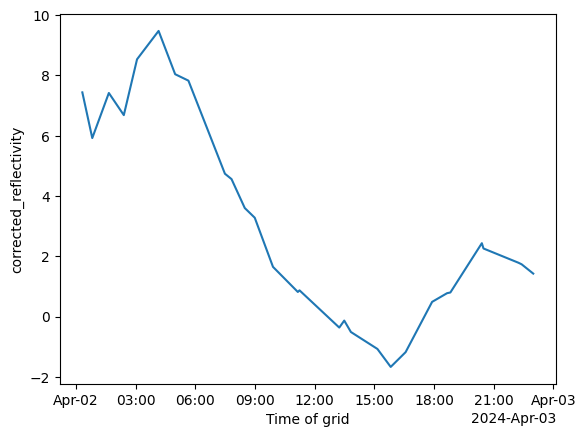

In [8]:
timeseries.plot()

In [10]:
# Select the radar data around the maximum time
radar_at_max = radar['corrected_reflectivity'].sel({'time': '20240402T0500'}, method='nearest')

# Visualising the observations

From this time-series we can identify times when there is likely to be a good amount of precipitation in the radar observation, and choose an appropriate moment to examine the data more closely.

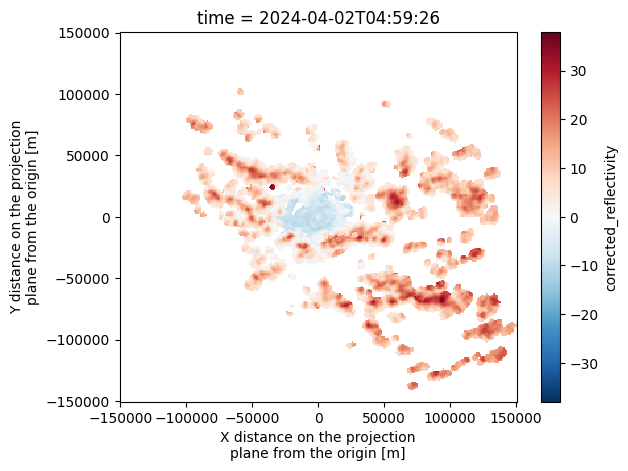

In [11]:
radar_at_max.mean(dim='z').plot()

# Visualising the radar data in three dimensions

The above plot shows the mean average reflectivity over x and y, collapsing the vertical dimension. It tells us where rain is likely to land, but doesn't tell us anything about the 3d-structure of the atmosphere. Visualising the data in 3D is not necessarily done often, but can be instructive. Morphological investigations are very complex!

We will need to convert the data type from the easy-to-use xarray format to a dense numpy array, as required by the visualisation library.

In [12]:
# Convert the data to numpy, choosing appropriate vertical slices.
# We set aside higher vertical levels with less precipitation present
# to allow more visual emphasis on the active layers

asnumpy = radar_at_max.sel({'z': slice(500, 6000)}).round(4).fillna(0).to_numpy()

In [ ]:
# asnumpy.shape
# Uncomment this to determine the dimensions for the meshgrid command below

In [14]:
# Make indexes
Z, X, Y = np.mgrid[500:6000:10j, -10:10:301j, -10:10:301j]
values = asnumpy

fig = go.Figure(
    data=go.Volume(
        x=X.flatten(),
        y=Y.flatten(),
        z=Z.flatten(),
        value=values.flatten(),
        isomin=-.99,
        isomax=0.99,
        opacity=0.01, # needs to be small to see through all surfaces
        surface_count=12, # needs to be a large number for good volume rendering,
        ),
    )

xaxis_dict = { 'title': {'text': 'Vertical distance (km)',
                         'font': {'size': 8}} }

zaxis_dict = { 'title': {'text': 'Height (m)',
                         'font': {'size': 8}} }

scene_dict = {
    'xaxis': xaxis_dict,
    'yaxis': xaxis_dict, # deliberately the same
    'zaxis': zaxis_dict,
}

fig.update_layout(
    title = "Radar reflectivity (volumetric view) - drag to rotate",
    scene_dragmode='turntable',
    autosize=False,
    width=1000,
    height=500,
    scene=scene_dict
)

fig.show()

Output hidden; open in https://colab.research.google.com to view.

**Make sure to click and drag the plot above! It's interactive, with an information popup if you mouse over it, and you can rotate and zoom on the data as well.**